In [1]:
from IPython.display import Image, display

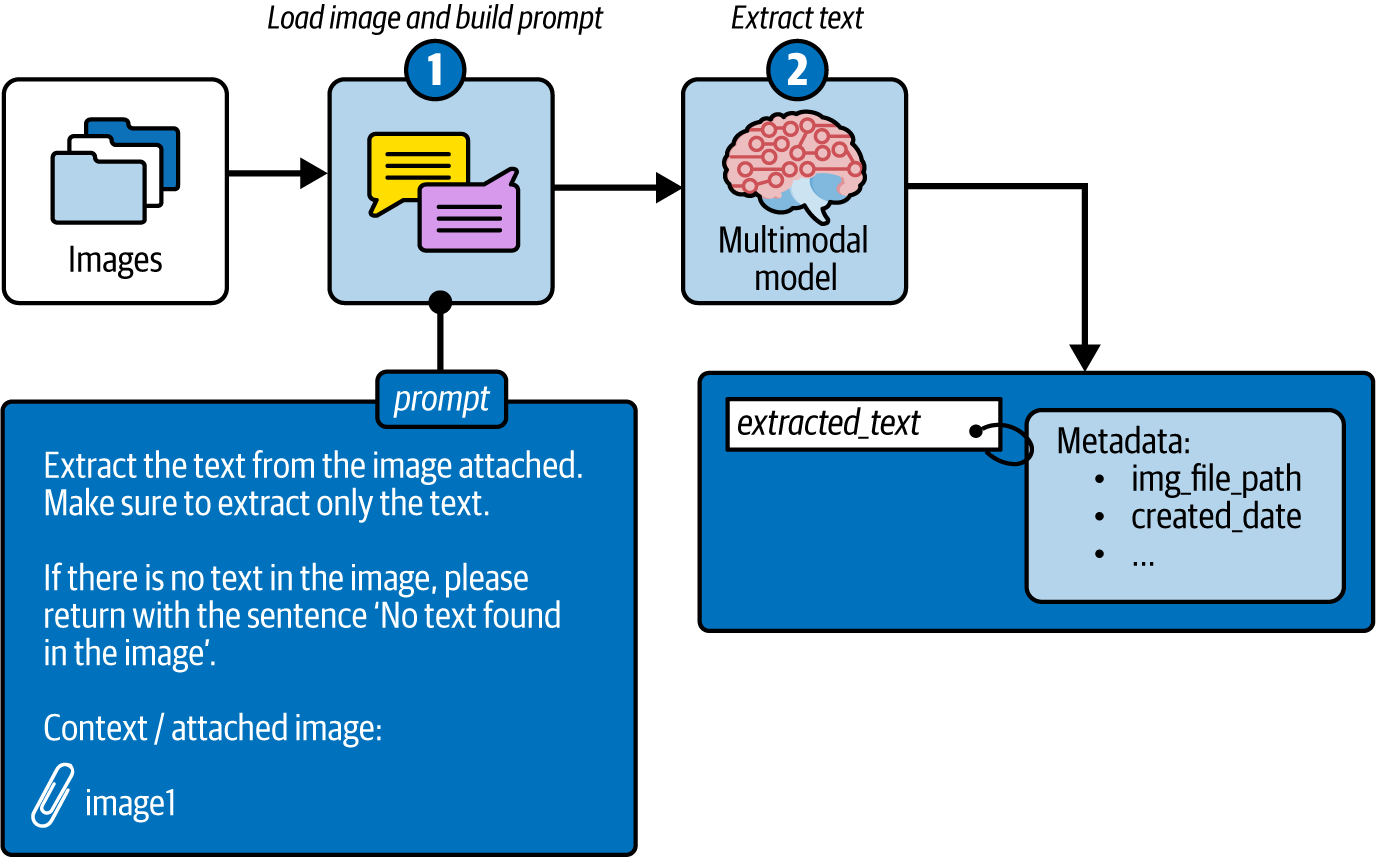

In [2]:
display(Image(filename="../images/14.png", width=500, height=500))

In [ ]:
import os
import base64
from openai import OpenAI

png_file_path = "../datasets/images/example_finance_reporting_slide.png"

# Initialize the OpenAI client
client = OpenAI()

with open(png_file_path, "rb") as image_file:
    base64_image = base64.b64encode(image_file.read()).decode("utf-8")

    prompt = (
        "Extract the text from the image attached. Make sure to only "
        "extract only the text. If there is no text in the image, "
        "please return with the sentence 'No text found in the image."
    )
    response = client.chat.completions.create(
        model="gpt-5.2",  # Define the model to use
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": (
                                f"data:image/jpeg;base64,"
                                f"{base64_image}"
                            ),
                        },
                    },
                ],
            }
        ],
        max_tokens=500,
    )
content = response.choices[0].message.content